In [1]:
!pip3 install google-adk litellm networkx matplotlib pandas


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import json                          # FIX 1: added – needed for JSON parsing in audit()
from dotenv import load_dotenv

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')

In [3]:
import pandas as pd
import io

# ── products ──────────────────────────────────────────────────────
products_csv = '''product_id,product_name,price,description
P001,ErgoDesk 120,249.99,Standing desk with adjustable height and reinforced frame.
P002,ComfyChair Pro,179.00,Ergonomic chair with lumbar support and breathable mesh.
P003,Oak Bookshelf,129.50,Solid oak bookshelf with 5 adjustable shelves.
'''

# ── parts ─────────────────────────────────────────────────────────
parts_csv = '''part_id,part_name,material,cost_usd
PT001,Steel Leg Set,Powder-coated steel,38.00
PT002,Desktop Panel,Laminated MDF,42.00
PT003,Adjustment Motor,Electric motor,55.00
PT004,Hex Bolt M8,Zinc steel,0.12
PT005,Chair Mesh Back,Mesh + plastic frame,18.50
PT006,Lumbar Support Pad,Foam,4.20
'''

# ── assemblies ────────────────────────────────────────────────────
assemblies_csv = '''assembly_id,assembly_name,product_id
A001,Desk Frame Assembly,P001
A002,Desk Top Assembly,P001
A003,Chair Back Assembly,P002
A004,Bookshelf Frame Assembly,P003
'''

# ── components (BOM) ──────────────────────────────────────────────
components_csv = '''assembly_id,part_id,quantity
A001,PT001,1
A001,PT003,1
A001,PT004,24
A002,PT002,1
A002,PT004,12
A003,PT005,1
A003,PT006,1
A003,PT004,8
A004,PT002,3
A004,PT004,30
'''

# ── suppliers ─────────────────────────────────────────────────────
suppliers_csv = '''supplier_id,supplier_name,rating,country
S001,SteelWorks Ltd,4.6,USA
S002,WoodCraft Co,4.3,USA
S003,FastenRight,4.7,USA
'''

# ── part → supplier mapping ───────────────────────────────────────
mapping_csv = '''part_id,supplier_id,unit_cost_usd,quality_rating,lead_time_days
PT001,S001,38.00,4.7,14
PT003,S001,55.00,4.4,21
PT002,S002,42.00,4.2,10
PT005,S002,18.50,4.1,12
PT006,S002,4.20,4.6,7
PT004,S003,0.12,4.8,5
'''

# ── reviews ───────────────────────────────────────────────────────
REVIEWS_TEXT = '''# Product Reviews

## P001 — ErgoDesk 120
- The desk is sturdy, but the motor sometimes stalls near the top height.
- Love the frame, but a few bolts arrived slightly stripped.

## P002 — ComfyChair Pro
- Great lumbar support at first, but the mesh back started squeaking after two weeks.
- Comfortable seat, but the back frame feels a bit flimsy.

## P003 — Oak Bookshelf
- Looks beautiful, but one of the side panels had a small crack.
- Easy to assemble; however the shelves sag a little when fully loaded.
'''

# Load into DataFrames
products_df   = pd.read_csv(io.StringIO(products_csv))
parts_df      = pd.read_csv(io.StringIO(parts_csv))
assemblies_df = pd.read_csv(io.StringIO(assemblies_csv))
components_df = pd.read_csv(io.StringIO(components_csv))
suppliers_df  = pd.read_csv(io.StringIO(suppliers_csv))
mapping_df    = pd.read_csv(io.StringIO(mapping_csv))

print('✅ Data loaded')
for name, df in [('Products', products_df), ('Parts', parts_df),
                 ('Assemblies', assemblies_df), ('Components', components_df),
                 ('Suppliers', suppliers_df), ('Mapping', mapping_df)]:
    print(f'   {name:12s}: {len(df)} rows')

✅ Data loaded
   Products    : 3 rows
   Parts       : 6 rows
   Assemblies  : 4 rows
   Components  : 10 rows
   Suppliers   : 3 rows
   Mapping     : 6 rows


In [4]:
suppliers_df

,supplier_id,supplier_name,rating,country
0,S001,SteelWorks Ltd,4.6,USA
1,S002,WoodCraft Co,4.3,USA
2,S003,FastenRight,4.7,USA


## NetworkX Knowledge Graph
NetworkX = offline/in-memory graph. Neo4j = online graph (like PostgreSQL for graphs).

In [5]:
import networkx as nx

KG = nx.DiGraph()

# Product nodes
for _, row in products_df.iterrows():
    KG.add_node(row['product_id'], label='product', name=row['product_name'],
                price=row['price'], description=row['description'])

# Part nodes
for _, row in parts_df.iterrows():
    KG.add_node(row['part_id'], label='part', name=row['part_name'],
                material=row['material'], cost_usd=row['cost_usd'])

# Assembly nodes + Assembly → Product edges
for _, row in assemblies_df.iterrows():
    KG.add_node(row['assembly_id'], label='assembly', name=row['assembly_name'])
    KG.add_edge(row['assembly_id'], row['product_id'], relation='HAS_ASSEMBLY')

# Assembly → Part edges (BOM)
for _, row in components_df.iterrows():
    KG.add_edge(row['assembly_id'], row['part_id'],
                relation='HAS_COMPONENT', quantity=row['quantity'])

# Supplier nodes
for _, row in suppliers_df.iterrows():
    KG.add_node(row['supplier_id'], label='supplier', name=row['supplier_name'],
                rating=row['rating'], country=row['country'])

# Part → Supplier edges
for _, row in mapping_df.iterrows():
    KG.add_edge(row['part_id'], row['supplier_id'],
                relation='SUPPLIED_BY', unit_cost_usd=row['unit_cost_usd'],
                quality_rating=row['quality_rating'], lead_time_days=row['lead_time_days'])

print('Knowledge Graph built')
print(f'   Nodes : {KG.number_of_nodes()}')
print(f'   Edges : {KG.number_of_edges()}')

Knowledge Graph built
   Nodes : 16
   Edges : 20


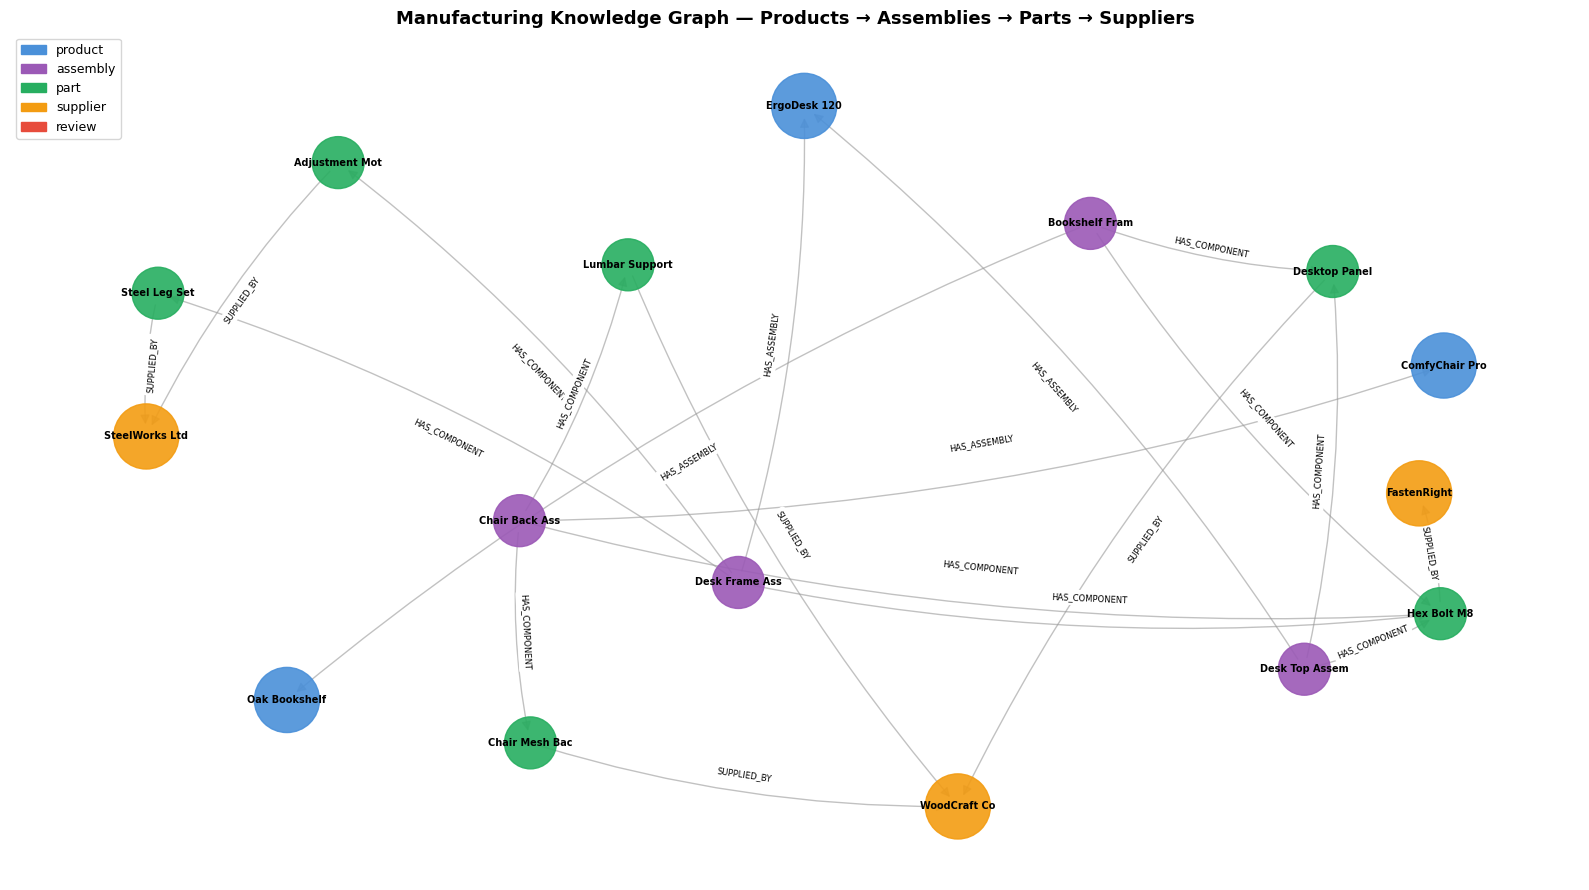

Graph saved as knowledge_graph.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# FIX 2: COLOR_MAP keys changed to lowercase to match the label values stored
#         in the graph nodes ('product', 'assembly', 'part', 'supplier', 'review').
#         Previously keys were Title-case ('Product', 'Assembly', …) causing ALL
#         nodes to render as grey (#ccc) because no key ever matched.
COLOR_MAP = {
    'product':  '#4A90D9',
    'assembly': '#9B59B6',
    'part':     '#27AE60',
    'supplier': '#F39C12',
    'review':   '#E74C3C',
}

fig, ax = plt.subplots(figsize=(16, 9))
node_colors = [COLOR_MAP.get(KG.nodes[n].get('label', ''), '#ccc') for n in KG.nodes]
node_sizes  = [2200 if KG.nodes[n].get('label') in ('product', 'supplier') else 1400
               for n in KG.nodes]
labels_map  = {n: KG.nodes[n].get('name', n)[:14] for n in KG.nodes}

pos = nx.spring_layout(KG, seed=42, k=2.2)
nx.draw_networkx_nodes(KG, pos, node_color=node_colors, node_size=node_sizes, ax=ax, alpha=0.9)
nx.draw_networkx_labels(KG, pos, labels=labels_map, font_size=7, font_weight='bold', ax=ax)
nx.draw_networkx_edges(KG, pos, edge_color='#999', arrows=True, arrowsize=14,
                       connectionstyle='arc3,rad=0.08', ax=ax, alpha=0.6)
edge_labels = {(u, v): KG[u][v].get('relation', '') for u, v in KG.edges}   # FIX 3: was .get('rel') but edges store key 'relation'
nx.draw_networkx_edge_labels(KG, pos, edge_labels=edge_labels, font_size=6, ax=ax)

legend = [mpatches.Patch(color=v, label=k) for k, v in COLOR_MAP.items()]
ax.legend(handles=legend, fontsize=9, loc='upper left')
ax.set_title('Manufacturing Knowledge Graph — Products → Assemblies → Parts → Suppliers',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('knowledge_graph.png', dpi=120, bbox_inches='tight')
plt.show()
print('Graph saved as knowledge_graph.png')

## Pydantic Schemas for the Workflow

In [7]:
from pydantic import BaseModel
from typing import List


class AuditInput(BaseModel):
    product_name: str


class ReviewSummary(BaseModel):
    product_name: str
    product_id: str
    issues: List[str]
    has_complaints: bool


class SupplierRisk(BaseModel):
    product_name: str
    suspect_suppliers: List[str]
    failing_parts: List[str]
    risk_summary: str


# FIX 4: New Pydantic model wrapping the final text report.
#         ADK's output_schema must be a Pydantic BaseModel so it can
#         validate and JSON-serialise the LLM response. Using bare `str`
#         caused JSONDecodeError because json.loads() received plain text.
class RiskReport(BaseModel):
    report: str

## Function Nodes

In [8]:
from google.adk import Event
from google.genai import types


def parse_audit_request_fn(node_input) -> AuditInput:
    """Convert the incoming chat message into the typed workflow input."""
    if isinstance(node_input, AuditInput):
        return node_input
    if isinstance(node_input, dict):
        return AuditInput.model_validate(node_input)
    if isinstance(node_input, types.Content):
        product_name = "\n".join(
            part.text.strip()
            for part in (node_input.parts or [])
            if getattr(part, 'text', None)
        ).strip()
        if not product_name:
            raise ValueError('Expected the user message to contain a product name.')
        return AuditInput(product_name=product_name)
    raise TypeError(f'Unsupported workflow input type: {type(node_input).__name__}')


def load_graph_fn(node_input: AuditInput) -> AuditInput:
    if KG.number_of_nodes() == 0 or KG.number_of_edges() == 0:
        raise ValueError('Knowledge graph is empty.')
    return node_input


def build_graph_fn(node_input: ReviewSummary) -> ReviewSummary:
    pid = node_input.product_id
    for i, issue in enumerate(node_input.issues):
        rid = f'R{pid}_{i:02d}'
        KG.add_node(rid, label='review', text=issue, sentiment='negative')  # FIX 5: 'Review' → 'review' (lowercase) to match COLOR_MAP
        KG.add_edge(rid, pid, relation='ABOUT')                              # FIX 6: 'rel' → 'relation' to match all other edges
    return node_input


def router_fn(node_input: ReviewSummary) -> Event:
    route = 'HAS_COMPLAINTS' if node_input.has_complaints else 'NO_COMPLAINTS'
    print(f'  [router_fn] Route for {node_input.product_name}: {route}')
    return Event(output=node_input, route=route)


def trace_suppliers_fn(node_input: ReviewSummary) -> SupplierRisk:
    pid = node_input.product_id
    suspect_suppliers = set()
    failing_parts = set()

    for asm_id in KG.predecessors(pid):
        if KG.nodes[asm_id].get('label') != 'assembly':
            continue
        for part_id in KG.successors(asm_id):
            if KG.nodes[part_id].get('label') != 'part':
                continue
            part_name = KG.nodes[part_id].get('name', part_id)
            keywords = [w for w in part_name.lower().split() if len(w) > 3]
            matched = any(
                any(kw in issue.lower() for kw in keywords)
                for issue in node_input.issues
            )
            if not matched:
                continue
            failing_parts.add(part_name)
            for sup_id in KG.successors(part_id):
                if KG.nodes[sup_id].get('label') != 'supplier':
                    continue
                sname  = KG.nodes[sup_id].get('name', sup_id)
                rating = KG.nodes[sup_id].get('rating', '?')
                suspect_suppliers.add(f'{sname} (rating: {rating})')

    return SupplierRisk(
        product_name=node_input.product_name,
        suspect_suppliers=sorted(suspect_suppliers),
        failing_parts=sorted(failing_parts),
        risk_summary=(
            f'{len(suspect_suppliers)} supplier(s) linked to '
            f'{len(failing_parts)} failing part(s)'
        ),
    )


def all_clear_fn(node_input: ReviewSummary) -> Event:
    msg = f'No complaints found for {node_input.product_name}'
    return Event(message=msg)

## Agent Nodes

In [9]:
from google.adk import Agent
from google.adk.models.lite_llm import LiteLlm

GPT = LiteLlm('gpt-4o-mini')

# Agent 1 — extract review issues and map to ReviewSummary schema
extract_reviews_agent = Agent(
    name='extract_reviews_agent',
    model=GPT,
    input_schema=AuditInput,
    output_schema=ReviewSummary,
    instruction=(
        'You are a quality analyst. Extract all complaints and issues for '
        '{AuditInput.product_name} from the product reviews below.\n\n'
        'REVIEWS:\n'
        + REVIEWS_TEXT +
        '\n\nReturn a JSON object with these fields:\n'
        '- product_name: the exact product name given\n'
        '- product_id: P001 for ErgoDesk 120, P002 for ComfyChair Pro, P003 for Oak Bookshelf\n'
        '- issues: list of specific problems mentioned (each as a short sentence)\n'
        '- has_complaints: true if any issues found, false otherwise\n'
        'Be specific — name the component (motor, bolt, mesh, panel etc.) in each issue.'
    ),
)

# Agent 2 — write a risk report from SupplierRisk data
# FIX 7: output_schema was bare `str`, which is not a valid Pydantic model.
#         ADK calls json.loads() on the LLM response whenever output_schema is set,
#         so a plain text answer raises JSONDecodeError.
#         Changed to RiskReport (a proper BaseModel with a single `report: str` field).
# FIX 8: instruction now explicitly asks the model to respond as
#         {"report": "<full text>"} so ADK's JSON parser succeeds.
risk_report_agent = Agent(
    name='risk_report_agent',
    model=GPT,
    input_schema=SupplierRisk,
    output_schema=RiskReport,          # FIX 7: was output_schema=str
    instruction=(
        'You are a supply chain risk manager. Write a concise risk report.\n\n'
        'Product      : {SupplierRisk.product_name}\n'
        'Failing parts: {SupplierRisk.failing_parts}\n'
        'Risk summary : {SupplierRisk.risk_summary}\n'
        'Suspect suppliers: {SupplierRisk.suspect_suppliers}\n\n'
        'Structure your report as:\n'
        '1. RISK SUMMARY (2 sentences)\n'
        '2. FAILING COMPONENTS (bullet list)\n'
        '3. FLAGGED SUPPLIERS (bullet list with ratings)\n'
        '4. RECOMMENDED ACTIONS (numbered, specific and actionable)\n'
        '5. PRIORITY: HIGH / MEDIUM / LOW\n'
        'Keep it under 200 words.\n\n'
        'IMPORTANT: Respond ONLY with a JSON object in this exact format:\n'  # FIX 8
        '{"report": "<your full report text here>"}'
    ),
)

## Workflow Graph

```
START
  └─ parse_audit_request_fn   (convert Content → AuditInput)
  └─ load_graph_fn            (validate KG is non-empty)
  └─ extract_reviews_agent    (AI: extract issues from reviews)
  └─ build_graph_fn           (add Review nodes to KG)
  └─ router_fn                (branch on has_complaints)
       ├─ HAS_COMPLAINTS
       │     └─ trace_suppliers_fn   (4-hop KG traversal)
       │     └─ risk_report_agent    (AI: write risk report)
       └─ NO_COMPLAINTS
             └─ all_clear_fn         (emit all-clear message)
```

In [10]:
from google.adk import Workflow

root_agent = Workflow(
    name='supply_chain_audit_workflow',
    edges=[
        # Main linear sequence from START
        ('START',
            parse_audit_request_fn,
            load_graph_fn,
            extract_reviews_agent,
            build_graph_fn,
            router_fn,
        ),
        # Conditional branches from router_fn
        (router_fn, {
            'HAS_COMPLAINTS': (trace_suppliers_fn, risk_report_agent),
            'NO_COMPLAINTS':  all_clear_fn,
        }),
    ],
)

print('✅ Workflow defined')

✅ Workflow defined


## Runner & Audit Function

In [11]:
import asyncio
from google.adk.runners import Runner
from google.adk.sessions import InMemorySessionService
from google.genai import types

session_service = InMemorySessionService()
runner = Runner(
    agent=root_agent,
    app_name='supply_chain_audit',
    session_service=session_service,
)


async def audit(product_name: str) -> str:
    """Run the full supply-chain audit workflow for one product."""
    session = await session_service.create_session(
        app_name='supply_chain_audit',
        user_id='analyst_1',
    )
    message = types.Content(
        role='user',
        parts=[types.Part(text=product_name)],
    )
    response = ''
    async for event in runner.run_async(
        user_id='analyst_1',
        session_id=session.id,
        new_message=message,
    ):
        if event.is_final_response() and event.content and event.content.parts:
            text = event.content.parts[0].text or ''
            # FIX 10: risk_report_agent returns {"report": "..."}.
            #         Safely unwrap the JSON; fall back to raw text for
            #         all_clear_fn responses which are plain strings.
            try:
                parsed   = json.loads(text)
                response = parsed.get('report', text) if isinstance(parsed, dict) else text
            except (json.JSONDecodeError, AttributeError):
                response = text
    return response


print('✅ Runner ready — call: await audit(product_name)')

✅ Runner ready — call: await audit(product_name)


## Visualise the Graph After Audit (with Review Nodes)

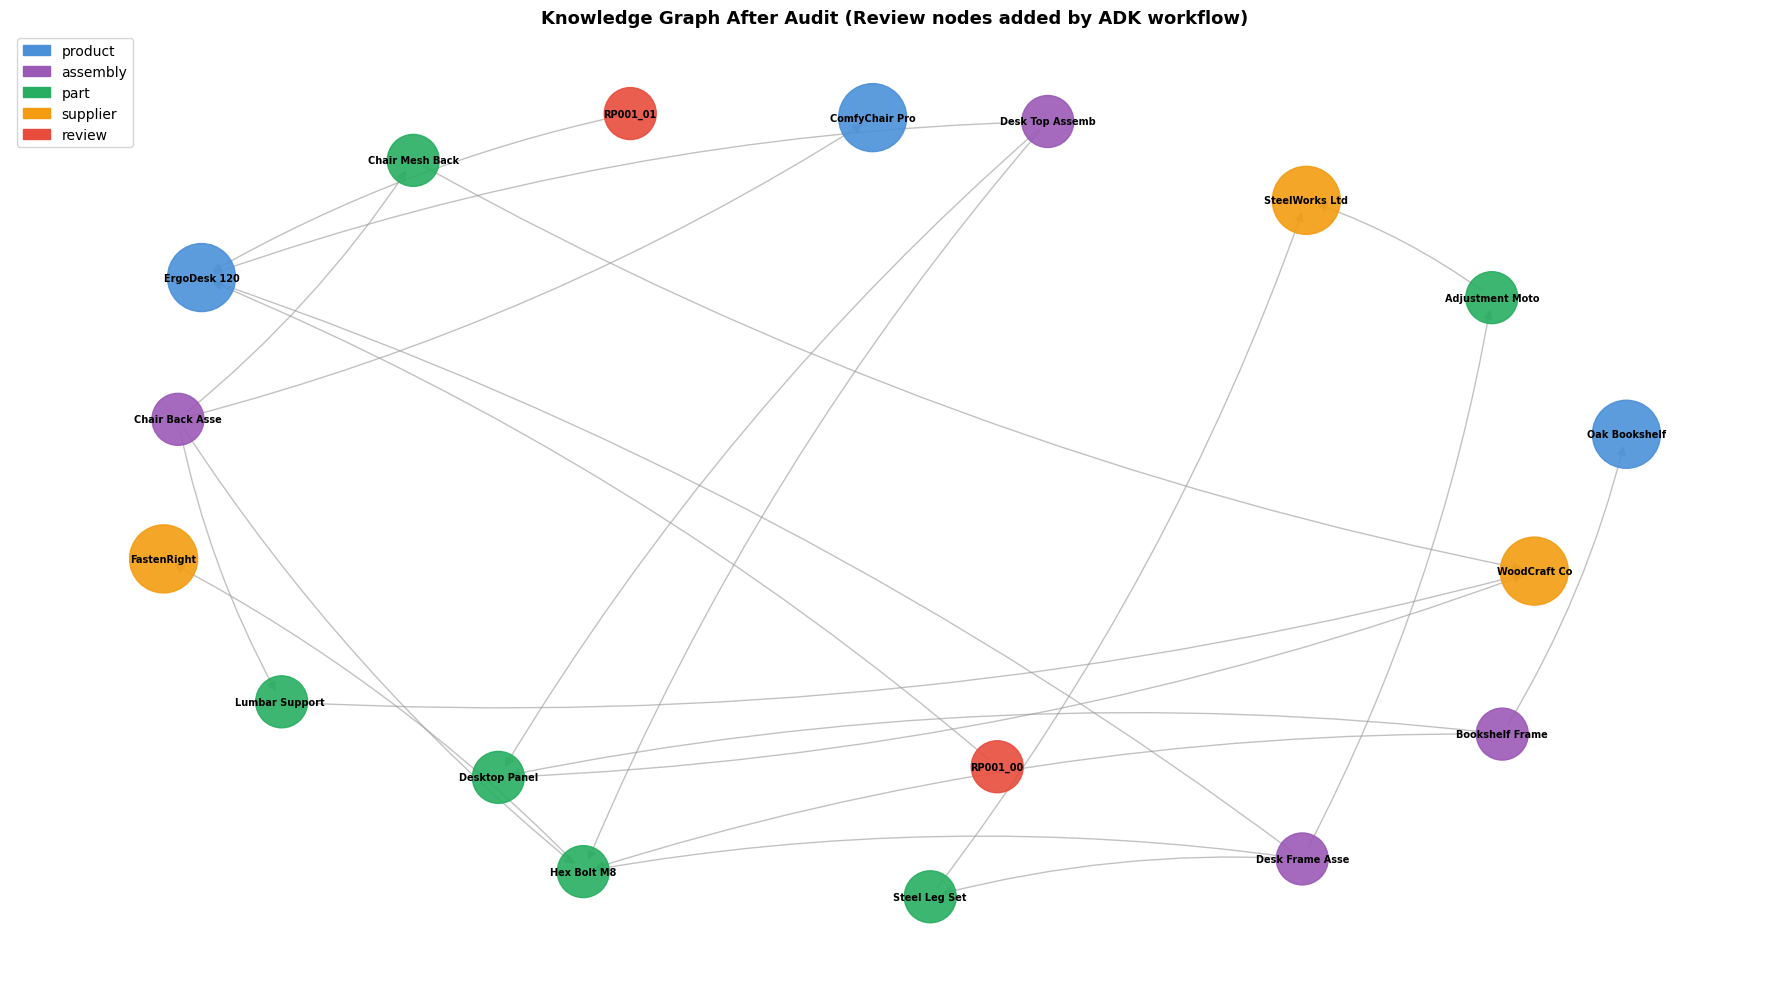

Post-audit graph stats:
   assembly    : 4 nodes
   part        : 6 nodes
   product     : 3 nodes
   review      : 2 nodes
   supplier    : 3 nodes


In [13]:
fig, ax = plt.subplots(figsize=(18, 10))
node_colors = [COLOR_MAP.get(KG.nodes[n].get('label', ''), '#ccc') for n in KG.nodes]
node_sizes  = [2400 if KG.nodes[n].get('label') in ('product', 'supplier') else 1400
               for n in KG.nodes]
labels_map  = {n: KG.nodes[n].get('name', n)[:15] for n in KG.nodes}

pos = nx.spring_layout(KG, seed=7, k=2.5)
nx.draw_networkx_nodes(KG, pos, node_color=node_colors, node_size=node_sizes, ax=ax, alpha=0.9)
nx.draw_networkx_labels(KG, pos, labels=labels_map, font_size=7, font_weight='bold', ax=ax)
nx.draw_networkx_edges(KG, pos, edge_color='#999', arrows=True, arrowsize=14,
                       connectionstyle='arc3,rad=0.08', ax=ax, alpha=0.6)

legend = [mpatches.Patch(color=v, label=k) for k, v in COLOR_MAP.items()]
ax.legend(handles=legend, fontsize=10, loc='upper left')
ax.set_title('Knowledge Graph After Audit (Review nodes added by ADK workflow)',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('knowledge_graph_post_audit.png', dpi=120, bbox_inches='tight')
plt.show()

from collections import Counter
labels_count = Counter(KG.nodes[n].get('label') for n in KG.nodes)
print('Post-audit graph stats:')
for label, count in sorted(labels_count.items()):
    print(f'   {label:12s}: {count} nodes')

## Manual Graph Queries

In [14]:
# FIX 11: All label comparisons corrected to lowercase to match node data.
#          Q3 edge-attribute keys corrected: unit_cost→unit_cost_usd, lead_days→lead_time_days.

print('Q1: What assemblies does ErgoDesk 120 have?')
for asm in KG.predecessors('P001'):          # assemblies point TO products
    if KG.nodes[asm].get('label') == 'assembly':
        print(f'   {asm}: {KG.nodes[asm]["name"]}')

print()
print('Q2: What parts go into the Desk Frame Assembly (A001)?')
for part in KG.successors('A001'):
    if KG.nodes[part].get('label') == 'part':
        qty = KG['A001'][part].get('quantity', '?')
        print(f'   {part}: {KG.nodes[part]["name"]} (qty: {qty})')

print()
print('Q3: Who supplies the Adjustment Motor (PT003)?')
for sup in KG.successors('PT003'):
    if KG.nodes[sup].get('label') == 'supplier':
        e = KG['PT003'][sup]
        print(f'   {KG.nodes[sup]["name"]} | quality: {e["quality_rating"]} '
              f'| cost: ${e["unit_cost_usd"]} | lead: {e["lead_time_days"]}d')

print()
print('Q4: Which products have Review nodes (complaints)?')
for node in list(KG.nodes):
    if KG.nodes[node].get('label') == 'review':
        for product in KG.successors(node):
            pname = KG.nodes[product].get('name', product)
            text  = KG.nodes[node].get('text', '')[:60]
            print(f'   {pname}: {text}...')

Q1: What assemblies does ErgoDesk 120 have?
   A001: Desk Frame Assembly
   A002: Desk Top Assembly

Q2: What parts go into the Desk Frame Assembly (A001)?
   PT001: Steel Leg Set (qty: 1)
   PT003: Adjustment Motor (qty: 1)
   PT004: Hex Bolt M8 (qty: 24)

Q3: Who supplies the Adjustment Motor (PT003)?
   SteelWorks Ltd | quality: 4.4 | cost: $55.0 | lead: 21d

Q4: Which products have Review nodes (complaints)?
   ErgoDesk 120: The motor sometimes stalls near the top height....
   ErgoDesk 120: A few bolts arrived slightly stripped....
